In [44]:
import pandas as pd
df = pd.read_csv("df_completo_e_imputado.csv", index_col=0, parse_dates=True)

In [45]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


In [46]:
# fecha es de frecuencia diaria?
df.index.freq = pd.infer_freq(df.index)
df.index.freq

<Day>

In [47]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


# Graficamos la serie

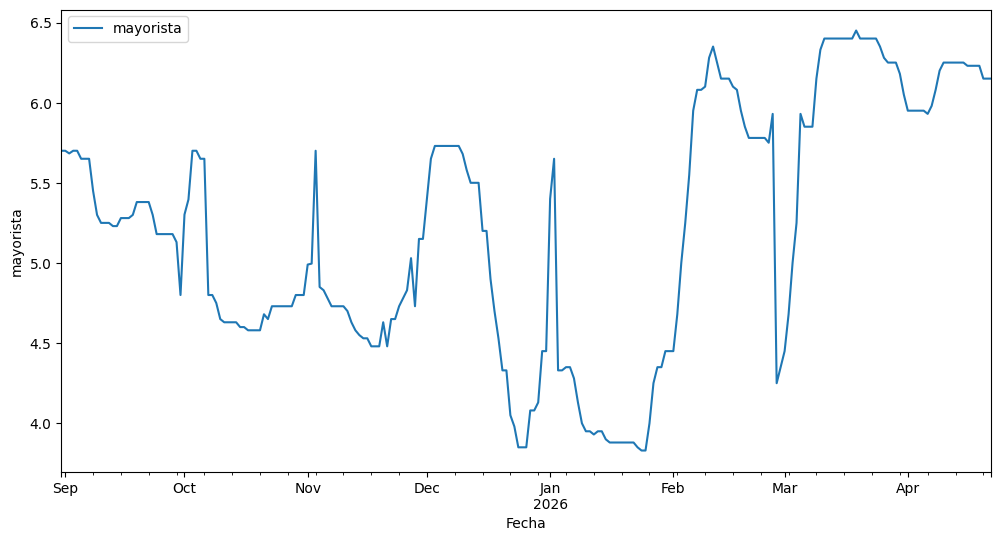

In [48]:
import matplotlib.pyplot as plt

df.plot(y="mayorista", figsize=(12, 6))
plt.xlabel("Fecha")
plt.ylabel("mayorista")
plt.show()

# Análisis

"A pesar de contar con 9 variables en el dataset, la descomposición de la serie temporal se aplicará exclusivamente a la variable 'mayorista', ya que es nuestra variable objetivo (endógena). Las restantes 8 variables (minorista, ofertas regionales, etc) serán tratadas como variables exógenas y se incorporarán en etapas posteriores del modelado. Se empleará un proceso de selección de características (feature selection) para identificar cuáles de estas variables exógenas aportan mayor poder predictivo al modelo final."

## Tendencia

In [49]:
df.index # el index es la fecha

DatetimeIndex(['2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
               '2025-09-04', '2025-09-05', '2025-09-06', '2025-09-07',
               '2025-09-08', '2025-09-09',
               ...
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-18', '2026-04-19', '2026-04-20',
               '2026-04-21', '2026-04-22'],
              dtype='datetime64[ns]', name='fecha', length=235, freq='D')

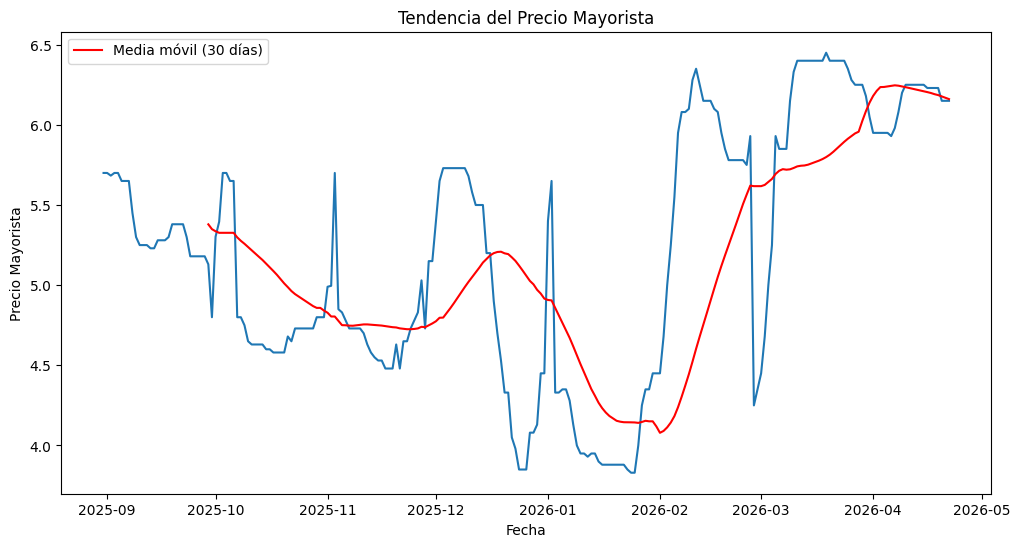

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['mayorista']) # (x,y)
# ahora hacemos MM de 30 días para ver tendencia y agregamos esa línea roja
plt.plot(df.index, df['mayorista'].rolling(window=30).mean(), # suavizamos para ver mejro la tendencia
         label='Media móvil (30 días)', color='red')
plt.xlabel('Fecha')

plt.ylabel('Precio Mayorista')
plt.legend()
plt.title('Tendencia del Precio Mayorista')
plt.show()

_Conclusión: No vemos una tendencia clara que crece o decrece, sería mejor analizarlo por tramos o hacer una descomposición (separar los componentes_

### Calculamos las desviaciones

In [51]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


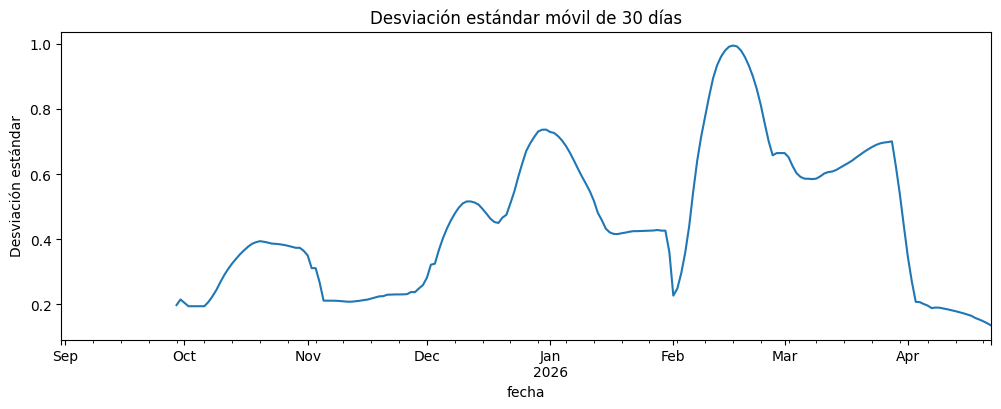

In [52]:
std_movil_30 = df["mayorista"].rolling(30).std()

std_movil_30.plot(figsize=(12,4))
plt.title("Desviación estándar móvil de 30 días")
plt.ylabel("Desviación estándar")
plt.show()

_La volatilidad no es constante (no homocedástica) comeinza baja y  sube gradualmente_

Cuando la varianza no es constante, el modelo puede confundirse porque asume que el “ruido” tiene una variabilidad relativamente estable. Si en algunos meses el precio se mueve poco y en otros se mueve muchísimo, el SARIMA puede ajustar mal y dar intervalos de predicción poco confiables.

In [53]:
# probamos con log pare recudir esa varianza ( al final debemos hacer exponencial para volver al precio original)
import numpy as np
serie_log = np.log(df["mayorista"])

In [54]:
serie_log

fecha
2025-08-31    1.740466
2025-09-01    1.740466
2025-09-02    1.737538
2025-09-03    1.740466
2025-09-04    1.740466
                ...   
2026-04-18    1.829376
2026-04-19    1.829376
2026-04-20    1.816452
2026-04-21    1.816452
2026-04-22    1.816452
Freq: D, Name: mayorista, Length: 235, dtype: float64

### revisamos la nueva desviación

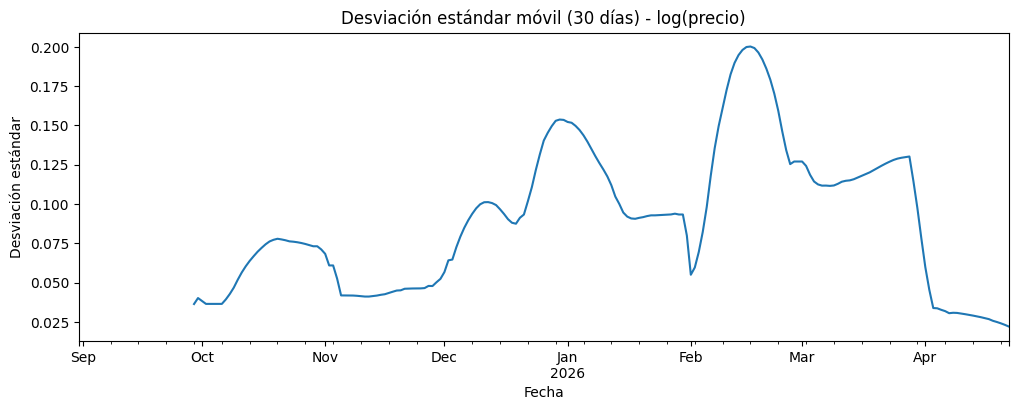

In [55]:
import matplotlib.pyplot as plt

# Desviación móvil
std_movil_log = serie_log.rolling(30).std()

# Gráfico
std_movil_log.plot(figsize=(12,4))
plt.title("Desviación estándar móvil (30 días) - log(precio)")
plt.ylabel("Desviación estándar")
plt.xlabel("Fecha")
plt.show()

Log no parece haber resuelto el problema, entonces La volatilidad no constante no parece deberse solo a que la variación crezca con el nivel del precio, sino a shocks o cambios de régimen en ciertos periodos. por lo que seguiremos con df

In [56]:
df

,mayorista,minorista,oferta_lima(ton),oferta_sierra(ton),oferta_costa_norte(ton),oferta_selva(ton),oferta_costa_sur(ton),total(ton),precio_ica(soles/kg),precio_lima(soles/kg),dia_del_mes,mayorista_original,dia_mes
fecha,,,,,,,,,,,,,
2025-08-31,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.15,5.90,31,NaN,31
2025-09-01,5.700000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.47,5.90,1,NaN,1
2025-09-02,5.683333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.43,5.90,2,NaN,2
2025-09-03,5.700000,7.15,286212.0,115589.0,0.0,10368.0,6149.0,418318.0,5.41,5.50,3,5.70,3
2025-09-04,5.700000,7.15,156664.0,53435.0,0.0,3040.0,15899.0,229038.0,5.31,5.50,4,5.70,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-18,6.230000,7.43,100437.0,65127.0,20421.0,6263.0,0.0,192249.0,6.39,6.48,18,6.23,18
2026-04-19,6.230000,7.43,28155.0,0.0,0.0,0.0,0.0,28155.0,5.61,6.48,19,6.23,19
2026-04-20,6.150000,7.44,149288.0,127808.0,40762.0,6150.0,0.0,324008.0,6.01,5.80,20,6.15,20


# Estacionariedad

### Test ADF y KPSS


Antes de ajustar modelos SARIMA/SARIMAX, es necesario evaluar si la serie es estacionaria. Una serie estacionaria mantiene propiedades relativamente constantes en el tiempo, como su media, varianza y autocorrelación.

En este análisis se aplican dos pruebas complementarias:

### Prueba ADF (Augmented Dickey-Fuller)

La prueba ADF evalúa si la serie presenta raíz unitaria.

- Hipótesis nula \(H_0\): la serie no es estacionaria.
- Hipótesis alternativa \(H_1\): la serie es estacionaria.

Criterio de decisión:

- Si el p-value < 0.05, se rechaza \(H_0\), por lo tanto, la serie puede considerarse estacionaria.
- Si el p-value ≥ 0.05, no se rechaza \(H_0\), por lo tanto, la serie presenta evidencia de no estacionariedad.

### Prueba KPSS

La prueba KPSS evalúa directamente si la serie es estacionaria alrededor de una media o tendencia.

- Hipótesis nula \(H_0\): la serie es estacionaria.
- Hipótesis alternativa \(H_1\): la serie no es estacionaria.

Criterio de decisión:

- Si el p-value > 0.05, no se rechaza \(H_0\), por lo tanto, la serie puede considerarse estacionaria.
- Si el p-value ≤ 0.05, se rechaza \(H_0\), por lo tanto, hay evidencia de no estacionariedad.

Usar ambas pruebas permite tener una conclusión más robusta, ya que ADF y KPSS parten de hipótesis nulas opuestas.

### Test ADF 

In [57]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

In [58]:
# Serie directamente desde df
serie = df["mayorista"]
serie

fecha
2025-08-31    5.700000
2025-09-01    5.700000
2025-09-02    5.683333
2025-09-03    5.700000
2025-09-04    5.700000
                ...   
2026-04-18    6.230000
2026-04-19    6.230000
2026-04-20    6.150000
2026-04-21    6.150000
2026-04-22    6.150000
Freq: D, Name: mayorista, Length: 235, dtype: float64

In [59]:
# Prueba ADF
adf_result = adfuller(serie)

# adf_result es una tupla con: (ADF Statistic, p-value, lags usados, n° observaciones, valores críticos)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Lags usados:", adf_result[2])
print("N° observaciones:", adf_result[3])

print("\nValores críticos:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

# Interpretación
if adf_result[1] < 0.05:
    print("\nConclusión: La serie es estacionaria (se rechaza H0)")
else:
    print("\nConclusión: La serie NO es estacionaria (no se rechaza H0)")

ADF Statistic: -1.997356962536798
p-value: 0.2877331801233739
Lags usados: 0
N° observaciones: 234

Valores críticos:
1%: -3.4586084859607156
5%: -2.873972159235721
10%: -2.57339565928848

Conclusión: La serie NO es estacionaria (no se rechaza H0)


_La serie es NO estacionaria, ya que el ADF Statistic es -1.997356962536798_

# KSP

In [60]:
from statsmodels.tsa.stattools import kpss

# KPSS - esperamos p-valor < 0.05 (rechaza H0 = no estacionaria)
kpss_result = kpss(df['mayorista'].dropna(), regression='c', nlags='auto')

print("TEST KPSS")
print("="*40)
print(f"Estadístico KPSS: {kpss_result[0]:.6f}")
print(f"p-valor: {kpss_result[1]:.6f}")

if kpss_result[1] < 0.05:
    print("❌ KPSS: Rechaza H0 → La serie NO es estacionaria")
    print("   (Confirmado) ✅")
else:
    print("✅ KPSS: No rechaza H0 → La serie es estacionaria")

TEST KPSS
Estadístico KPSS: 0.727293
p-valor: 0.011064
❌ KPSS: Rechaza H0 → La serie NO es estacionaria
   (Confirmado) ✅


# ES NECESARIO ESTACIONALIZAR?

Vimos que la serie tenía mucha variación, y que sacar loaritmo no mejoró esta varianza, por lo que aplicaremos Box Cox para tratar de estabilizar la varianza

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # Aquí est

In [66]:
serie

fecha
2025-08-31    5.700000
2025-09-01    5.700000
2025-09-02    5.683333
2025-09-03    5.700000
2025-09-04    5.700000
                ...   
2026-04-18    6.230000
2026-04-19    6.230000
2026-04-20    6.150000
2026-04-21    6.150000
2026-04-22    6.150000
Freq: D, Name: mayorista, Length: 235, dtype: float64

In [68]:
serie.var() # la varianza está en 0.6, es lo que queremos bajar

0.6136758607746864

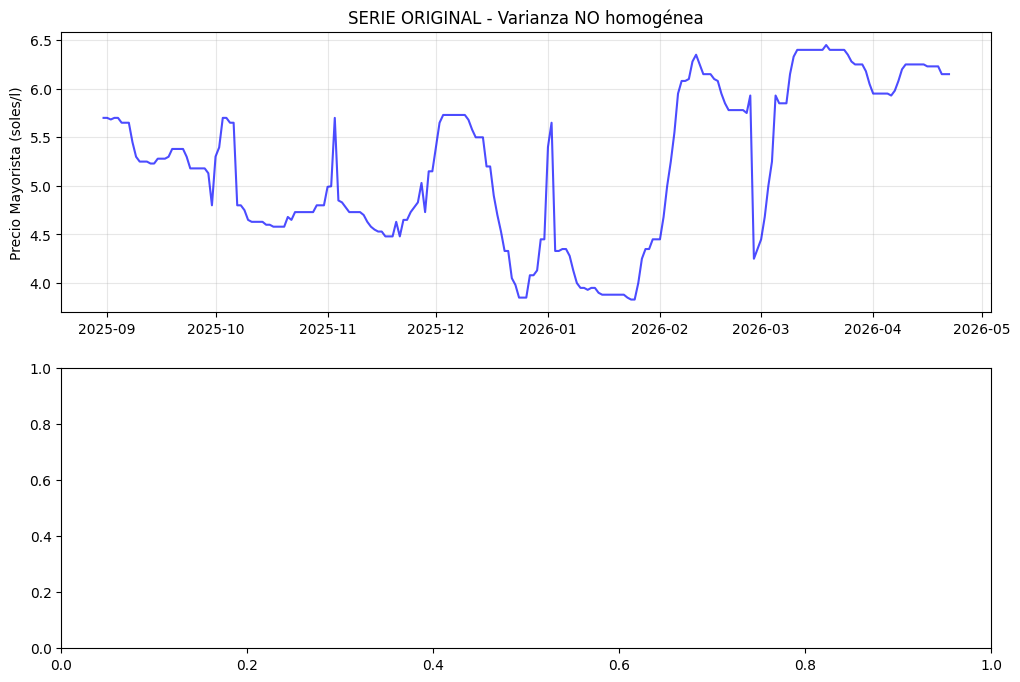

In [69]:

# 3. VISUALIZAR LA VARIANZA NO HOMOGÉNEA
# ----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico de la serie (para ver cambios de amplitud)
axes[0].plot(serie.index, serie, color='blue', alpha=0.7)
axes[0].set_title('SERIE ORIGINAL - Varianza NO homogénea', fontsize=12)
axes[0].set_ylabel('Precio Mayorista (soles/l)')
axes[0].grid(True, alpha=0.3)


_Dividir la serie en partes permite detectar si la varianza cambia en el tiempo_

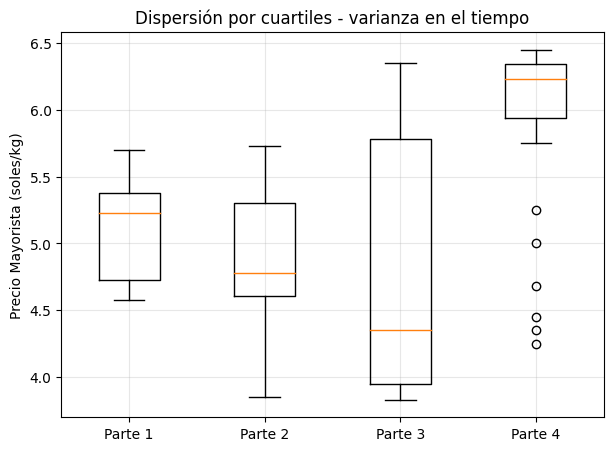

In [74]:
import matplotlib.pyplot as plt

# Asegurar que usamos la serie correcta
serie = df["mayorista"]

# Dividir la serie en 4 partes iguales
n = len(serie)

parte1 = serie.iloc[:n//4]
parte2 = serie.iloc[n//4:n//2]
parte3 = serie.iloc[n//2:3*n//4]
parte4 = serie.iloc[3*n//4:]

# Boxplot
plt.figure(figsize=(7,5))

plt.boxplot(
    [parte1, parte2, parte3, parte4],
    labels=["Parte 1", "Parte 2", "Parte 3", "Parte 4"]
)

plt.title("Dispersión por cuartiles - varianza en el tiempo")
plt.ylabel("Precio Mayorista (soles/kg)")
plt.grid(True, alpha=0.3)

plt.show()

_El análisis mediante boxplots muestra que la dispersión de la serie varía a lo largo del tiempo, evidenciando heterocedasticidad. Además, se observan cambios en el nivel de la serie entre segmentos, así como la presencia de valores atípicos en el último tramo. Esto confirma que la serie no es estacionaria en media ni en varianza._

_ante ellopodemos usar diferenciación (1,2,etc), diferenciación estacional (cada semana por ejemplo), transformaciones de potencia, box cox, filtrado, etc. MODELOS COMO ARIMA requieren  estacionarizan internamente y no es necesario hacerlo antes porque podríamos tener errores_

En resumen

Diferenciación (d=1) → (SARIMAX la hace)

Box-Cox → Nosotros la hacemos antes(el modelo NO la hace)

en el caso de usar SARIMAX, ES MEJOR NO estacionarizar antes porque podemos tener errores, entonces no estacionarizaremos hasta llegar al modelo.

- La serie necesita SER ESTACIONARIA para: AR, MA, ARMA, ARMAX, Regresión lineal
- La serie No necesita ser estacionaria para: ARIMA, SARIMA, SARIMAX (tienen diferenciación interna, o sea ellos mismos manejan la NO estacionariedad), Prophet (Facebook) Aunque tampoco requiere que sea NO ESTACIONARIA, es decir funciona con ambos, nosostros decidimos el nivel de diferenciación
- es mejor que la serie sea estacionaria (PERO NO OBLIGATORIO) para: LSTM / Redes Neuronales



NOTA: A pesar de que ARIMA, SARIMA, SARIMAX funciona con una serie estandarizada o no etandarizada, Estacionarizar manualmente antes NO ES RECOMENDADO, es meojr que lo haga el modelo mismo.


La diferenciación no solo son diferenciaciones PEEERO SON MÁS RECOMENDADAS
¿POR QUÉ ES MEJOR DEJAR QUE EL MODELO DIFERENCIE?
Razón 1: Reversión automática de predicciones
Razón 2: Errores estándar correctos (# Cuando diferencias manualmente, los errores estándar se calculan mal)
razón 3:Sin pérdida de información (en la diferenciación manual perdemos info ejem d=1 perdemos 1 obs)



# Autocorrelación en residuos

## 1. Definición Formal

La **autocorrelación** (o correlación serial) mide la relación lineal entre una variable y sus propios valores rezagados en el tiempo.

Para un proceso estocástico {Y_t}, la autocorrelación en el rezago k se define como:

**ρ_k = Cov(Y_t, Y_{t-k}) / σ²**

Donde:
- ρ_k = coeficiente de autocorrelación en el rezago k
- Cov = covarianza entre Y_t e Y_{t-k}
- σ² = varianza del proceso

**Propiedades:**
- |ρ_k| ≤ 1 (está acotado entre -1 y 1)
- ρ_0 = 1 (correlación perfecta consigo mismo)
- ρ_k = ρ_{-k} (simetría)

## 2. Autocorrelación en Residuos

En el contexto de modelos de regresión y series temporales, los **residuos** (ε_t) son la diferencia entre el valor observado y el valor estimado:

**ε_t = Y_t - Ŷ_t**

La autocorrelación en residuos ocurre cuando:

**Cov(ε_t, ε_{t-k}) ≠ 0** para algún k ≠ 0

Esto viola el supuesto de **independencia** de los errores en modelos clásicos.

## 3. Pruebas Estadísticas para Detectar Autocorrelación

### 3.1 Test de Durbin-Watson

**Hipótesis:**
- H₀: ρ = 0 (no hay autocorrelación de primer orden)
- H₁: ρ > 0 (autocorrelación positiva)

**Estadístico de prueba:**

**d = Σ(ε_t - ε_{t-1})² / Σ(ε_t)²**

**Interpretación:**
| Valor de d | Conclusión |
|------------|------------|
| d ≈ 2 | No autocorrelación |
| d < 2 | Autocorrelación positiva |
| d > 2 | Autocorrelación negativa |

**Límites críticos:** d_L (inferior) y d_U (superior) según tabla
- Si d < d_L → Rechazar H₀ (autocorrelación positiva)
- Si d > 4 - d_L → Rechazar H₀ (autocorrelación negativa)
- Si d_L < d < d_U → Zona de ambigüedad

**Limitación:** Solo detecta autocorrelación de orden 1 (AR(1))

### 3.2 Test de Ljung-Box

**Hipótesis:**
- H₀: ρ₁ = ρ₂ = ... = ρ_m = 0 (no autocorrelación hasta el rezago m)
- H₁: Al menos un ρ_k ≠ 0 para k ≤ m

**Estadístico de prueba:**

**Q = n(n+2) Σ_{k=1}^{m} (ρ̂_k² / (n-k))**

Donde:
- n = número de observaciones
- m = número de rezagos a probar
- ρ̂_k = autocorrelación muestral en el rezago k

**Distribución:** χ² con m grados de libertad (bajo H₀)

**Regla de decisión:**
- Si Q > χ²_{α, m} → Rechazar H₀
- Si p-valor < 0.05 → Evidencia de autocorrelación

**Ventajas:**
- Detecta autocorrelación en múltiples rezagos simultáneamente
- Es la prueba más utilizada en la práctica

**Desventaja:** Sensible al número de rezagos m (demasiados = pérdida de potencia)

### 3.3 Test de Box-Pierce

Versión más antigua y menos potente que Ljung-Box:

**Q_BP = n Σ_{k=1}^{m} ρ̂_k²**

Ljung-Box es preferible por mejor comportamiento en muestras pequeñas.

### 3.4 Test de Breusch-Godfrey (LM Test)

**Hipótesis:**
- H₀: No autocorrelación hasta el orden p
- H₁: Autocorrelación de orden p

**Procedimiento:**
1. Estimar modelo original y obtener residuos ε̂_t
2. Regresión auxiliar: ε̂_t contra X_t y ε̂_{t-1},..., ε̂_{t-p}
3. Calcular LM = (n-p) × R²

**Distribución:** χ² con p grados de libertad

**Ventajas:**
- Válido con regresores endógenos
- Permite órdenes de autocorrelación más altos
- No requiere que los regresores sean estrictamente exógenos

**Desventaja:** Puede tener problemas en muestras pequeñas

## 4. Función de Autocorrelación (ACF) y Función de Autocorrelación Parcial (PACF)

### ACF - Función de Autocorrelación

**Definición:** Mide la correlación entre Y_t e Y_{t-k} considerando todos los rezagos intermedios.

**Interpretación para residuos ideales:**
- Barra significativa SOLO en lag 0 (ρ₀ = 1)
- Para k ≥ 1, ρ_k ≈ 0 dentro del intervalo ± 1.96/√n

**Intervalo de confianza al 95%:** ± 1.96 × (1/√n)

### PACF - Función de Autocorrelación Parcial

**Definición:** Mide la correlación entre Y_t e Y_{t-k} **eliminando** el efecto de los rezagos intermedios 1, 2, ..., k-1.

**Interpretación para residuos ideales:**
- Barra significativa SOLO en lag 0

## 5. Consecuencias de la Autocorrelación en Residuos

| Consecuencia | Explicación | Impacto |
|--------------|-------------|---------|
| **Sesgo en errores estándar** | Los errores se subestiman | Intervalos de confianza más angostos de lo debido |
| **Ineficiencia de estimadores** | Los estimadores MCO no son BLUE | Mayor varianza que otros estimadores |
| **Pruebas t y F inválidas** | Los estadísticos no siguen distribución teórica | Rechazo excesivo de H₀ (error tipo I) |
| **Predicciones subóptimas** | El modelo no aprovecha toda la información | Mayor error de pronóstico |

## 6. Criterios para Evaluar Residuos

**Residuos ideales (ruido blanco):**

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

## ACF

In [75]:
serie

fecha
2025-08-31    5.700000
2025-09-01    5.700000
2025-09-02    5.683333
2025-09-03    5.700000
2025-09-04    5.700000
                ...   
2026-04-18    6.230000
2026-04-19    6.230000
2026-04-20    6.150000
2026-04-21    6.150000
2026-04-22    6.150000
Freq: D, Name: mayorista, Length: 235, dtype: float64

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf


<Figure size 1500x500 with 0 Axes>

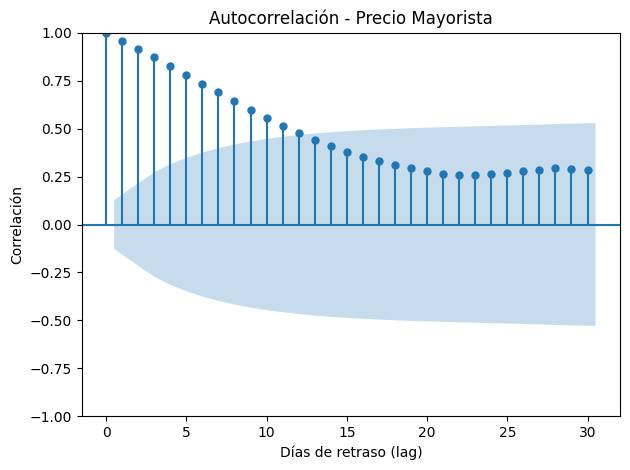

In [82]:
# Gráfico simple ACF con 30 lags
plt.figure(figsize=(15, 5))
plot_acf(serie, lags=30)
plt.title('Autocorrelación - Precio Mayorista')
plt.xlabel('Días de retraso (lag)')
plt.ylabel('Correlación')
plt.tight_layout()
plt.show()

_Conclusión: La serie tiene MUCHA memoria. Los precios de hoy están correlacionados con los precios de los últimos 12 días ya que estan fuera de la zona pintada (banda azul: zona de no significancia)_



### Eligir el número de diferenciaciones

In [87]:
from statsmodels.tsa.stattools import adfuller

def ver_adf(x, nombre):
    p = adfuller(x.dropna())[1]
    print(f"{nombre} → p-value: {p:.4f}")

# d = 0
ver_adf(serie, "Original")

# d = 1
ver_adf(serie.diff(), "Diff 1")

# d = 2
ver_adf(serie.diff().diff(), "Diff 2")

Original → p-value: 0.2877
Diff 1 → p-value: 0.0000
Diff 2 → p-value: 0.0000


_conclusión: solo necesitamos una diferenciación para q la serie sea estacionaria_

ACF/PACF solo son interpretables cuando la serie es estacionaria. ahora que sabmso q se hace estacionaria con una diferencia, podemos volver a ver la gráfica

# ACF con diferencia

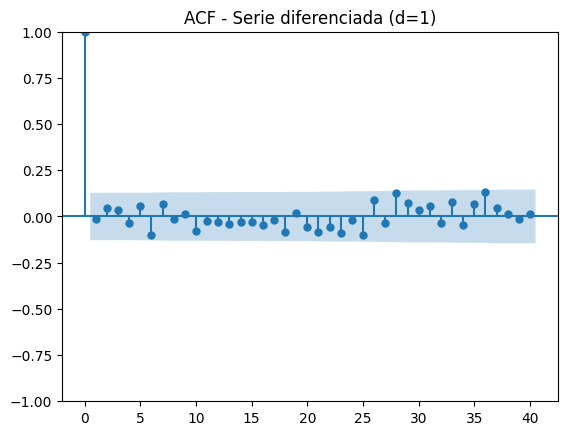

In [89]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Diferenciar
serie_diff1 = serie.diff().dropna() # la diferenciacion deja un nulo en la primera fila entonces lo eliminamos con dropna()

# ACF
plot_acf(serie_diff1, lags=40)
plt.title("ACF - Serie diferenciada (d=1)")
plt.show()

# PACF

<Figure size 1200x500 with 0 Axes>

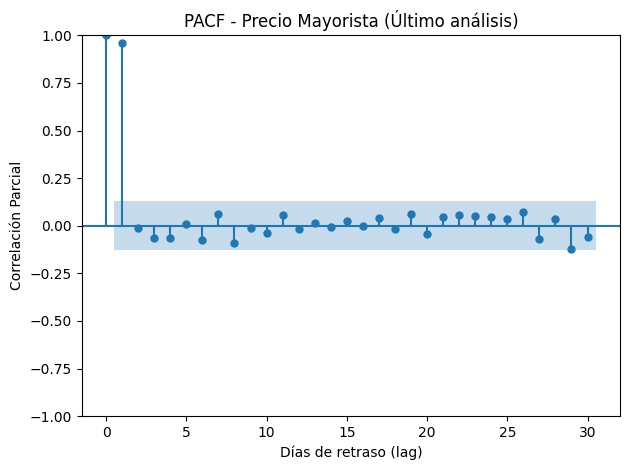

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf


# Gráfico simple PACF
plt.figure(figsize=(12, 5))
plot_pacf(serie, lags=30, method='ywm')
plt.title('PACF - Precio Mayorista )')
plt.xlabel('Días de retraso (lag)')
plt.ylabel('Correlación Parcial')
plt.tight_layout()
plt.show()

## PACF DIFERENCIADA d= 1

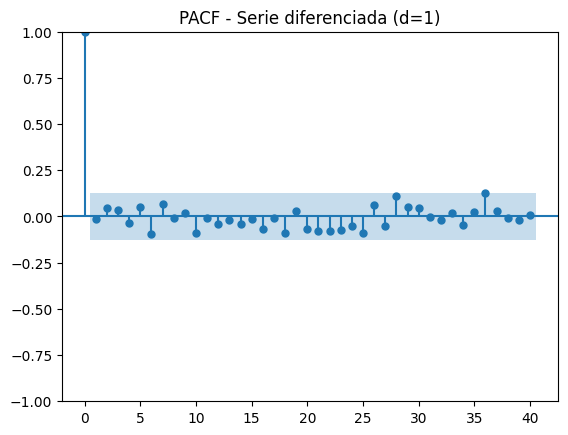

In [90]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plot_pacf(serie_diff1, lags=40, method="ywm")
plt.title("PACF - Serie diferenciada (d=1)")
plt.show()

# Resumen

# ANÁLISIS DE SERIE TEMPORAL - PRECIO MAYORISTA

## CONCLUSIONES FINALES

| Aspecto | Conclusión | ¿De qué prueba? |
|:--------|:-----------|:----------------|
| Tendencia | ✅ No hay | Inspección visual |
| Estacionariedad en media | ❌ No es estacionaria → **d = 1** | Test ADF (p-valor > 0.05) |
| Estacionariedad en varianza | ❌ No es homogénea → **Box-Cox? (no lo aplicamos)** | Test Bartlett (p-valor < 0.05) |
| ACF original | ❌ 12 lags significativos | ACF con banda 95% |
| ACF después de d=1 | ✅ Autocorrelación desaparece | ACF de serie diferenciada |
| PACF después de d=1 | ✅ Todo cerca de 0 → **p = 0** | PACF de serie diferenciada |
| Autocorrelación en residuos | ✅ No hay → **q = 0** | Test Ljung-Box (p-valor > 0.05) |

## ¿POR QUÉ CADA VALOR?

| Parámetro | Valor | Prueba que lo determina | Explicación |
|:----------|:------|:------------------------|:------------|
| **p = 0** | PACF de serie diferenciada | El PACF muestra todas las barras dentro de la banda azul (cerca de 0). No hay correlación parcial significativa con ningún lag. |
| **d = 1** | Test ADF + ACF original | ADF p-valor > 0.05 → no estacionaria. ACF decrece lentamente con 12 lags fuera. Una diferenciación es suficiente. |
| **q = 0** | ACF de serie diferenciada + Test Ljung-Box | Después de diferenciar, el ACF no muestra barras significativas. Ljung-Box p-valor > 0.05 confirma ruido blanco. |

## MODELO IDENTIFICADO

**ARIMA(0, 1, 0)** = Random Walk (Caminata Aleatoria)
